In [ ]:
## This program uses an artificial recurrent neural network called Long Short Term Memory(LSTM)
# to predict the closing stock price of a multiple corporations using the past 60 day stock prices of specific corporation


In [ ]:
import math
import pandas_datareader as web
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [ ]:
import re
import json

def _read_one_data(self, url, params):
    resp = self._get_response(url, params=params)
    if resp.text is None:
        raise ValueError("No data found for symbol {}".format(self.symbols))

    ptrn = r"root\.App\.main = (.*?);\n}\(this\)\;"
    try:
        j = json.loads(re.search(ptrn, resp.text, re.DOTALL).group(1))
        data = j["context"]["dispatcher"]["stores"]["HistoricalPriceStore"]
    except KeyError:
        raise ValueError("No data found for symbol {}".format(self.symbols))

    return data

In [ ]:
#Getting stock quote
import pandas_datareader as web
stocks = ['AAPL', 'MSFT', 'GOOG', 'NVDA', 'META', 'AMZN']
for stock in stocks:
  print(f"Processing {stock}.")
  df = web.DataReader(stock, data_source ='stooq', start = '2012-01-01', end = '2019-12-17')
  df.sort_values(by = ['Date'], inplace = True)
  # show the data
  print(df)

In [38]:
# Get number of rows and columns in data set
for stock in stocks:
  print(f"Processing {stock}.")
  print(df.shape)


Processing AAPL.
(2003, 5)
Processing MSFT.
(2003, 5)
Processing GOOG.
(2003, 5)
Processing NVDA.
(2003, 5)
Processing META.
(2003, 5)
Processing AMZN.
(2003, 5)


Processing AAPL.


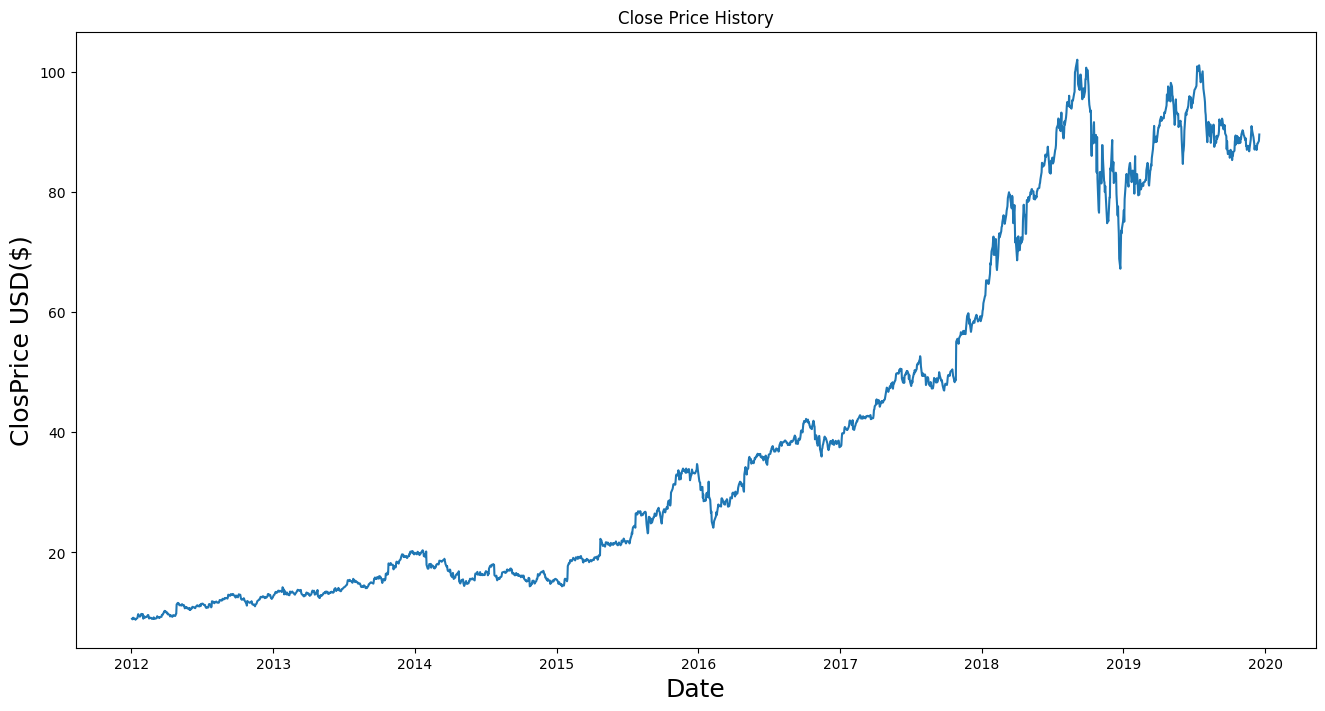

Processing MSFT.


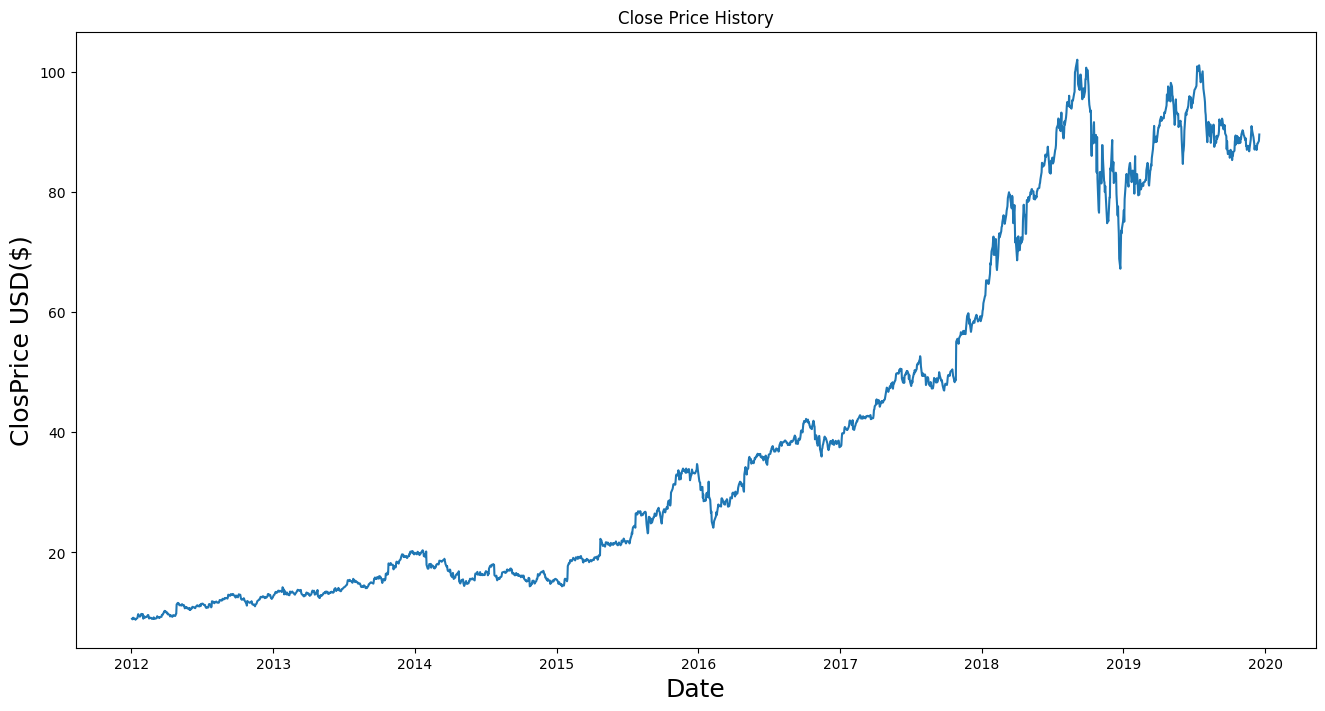

Processing GOOG.


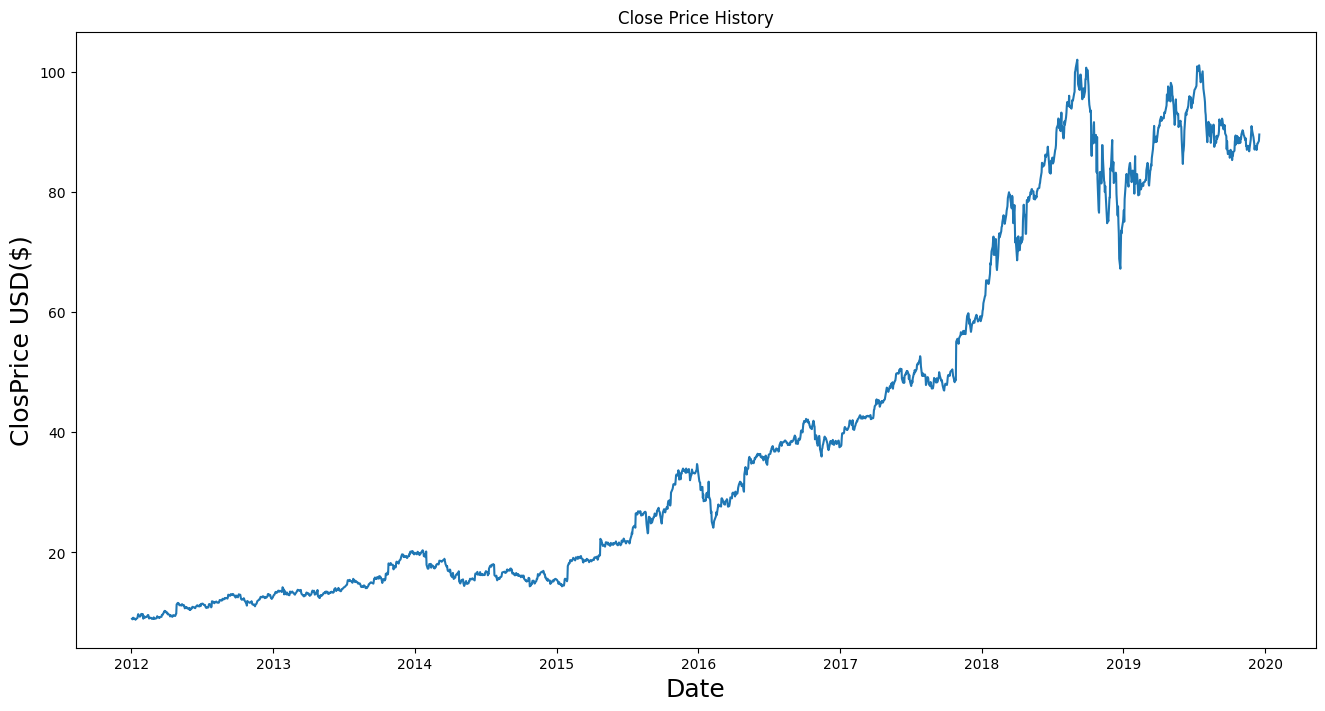

Processing NVDA.


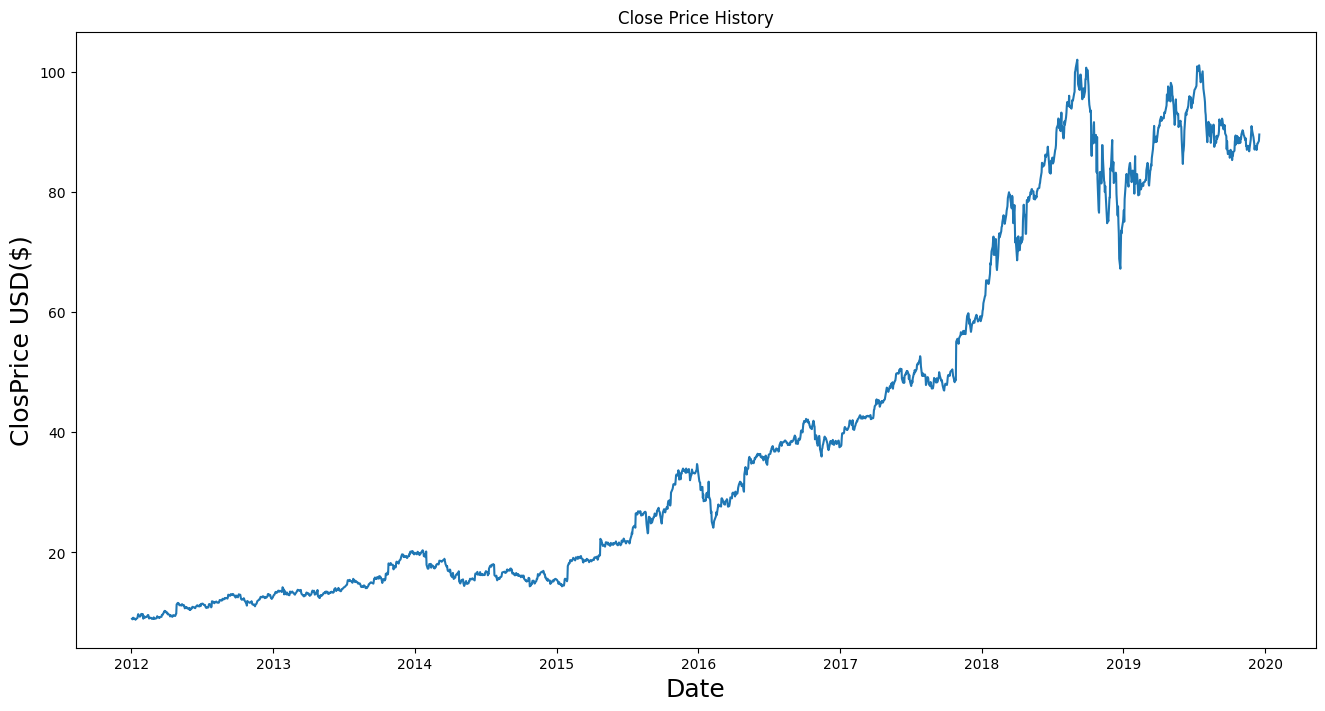

Processing META.


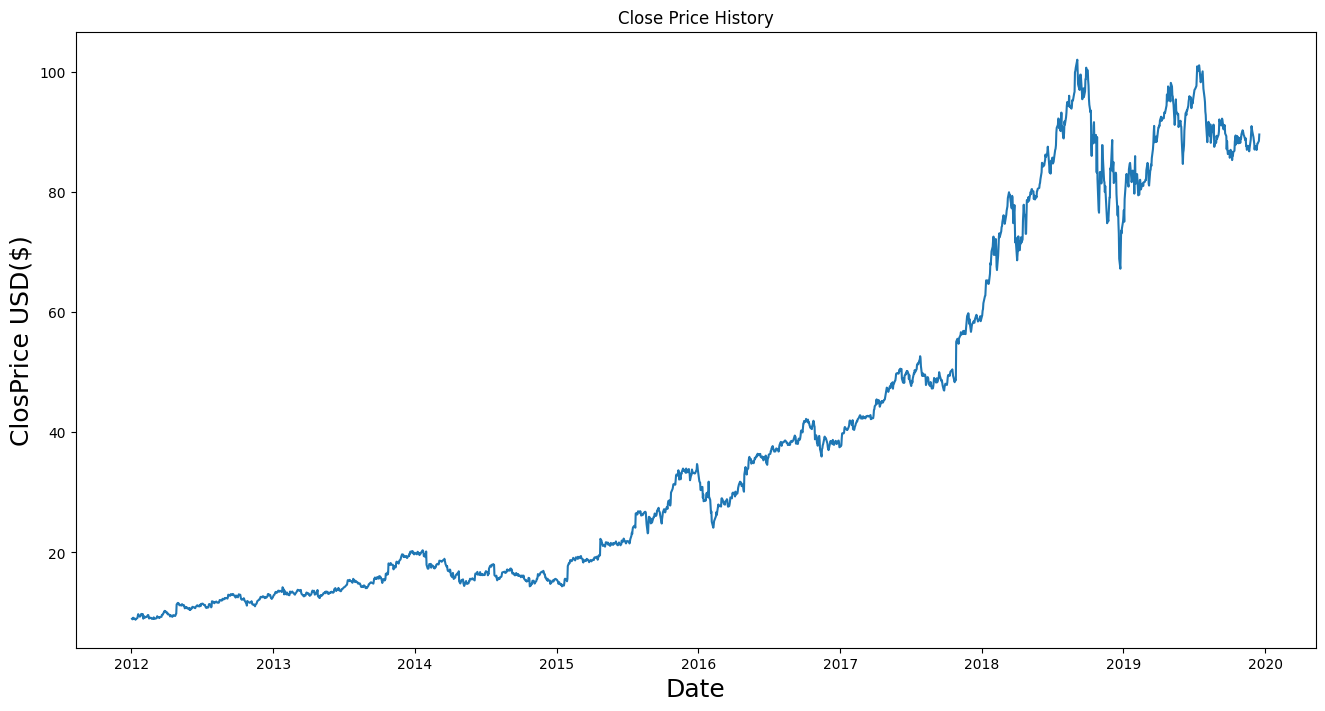

Processing AMZN.


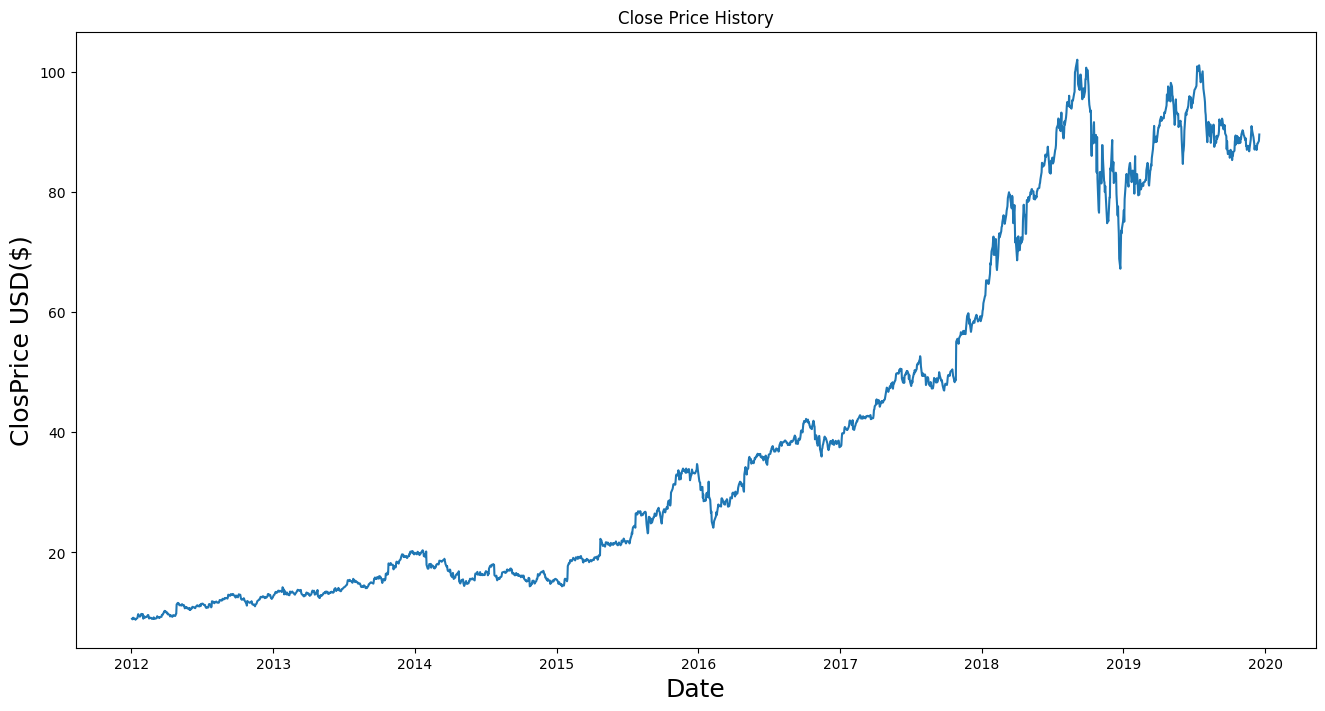

In [36]:
#Visualize the closing prive history
import matplotlib.pyplot as plt
for stock in stocks:
  print(f"Processing {stock}.")
  plt.figure(figsize = (16,8))
  plt.title('Close Price History')
  plt.plot(df['Close'])
  plt.xlabel('Date', fontsize = 18)
  plt.ylabel('ClosPrice USD($)', fontsize =18)
  plt.show()

In [39]:
# Create a new dataframe with only the 'Close column
import math
for stock in stocks:
  print(f"Processing {stock}.")
  data = df.filter(['Close'])
  # Convert the dataframe to a numpy array
  dataset = data.values
  # Get the number of rows to train LSTM model on 80% of data
  training_data_len = math.ceil( len(dataset)  * .8)
  print(training_data_len)

Processing AAPL.
1603
Processing MSFT.
1603
Processing GOOG.
1603
Processing NVDA.
1603
Processing META.
1603
Processing AMZN.
1603


In [40]:
# Scale the data
from sklearn.preprocessing import MinMaxScaler
for stock in stocks:
  print(f"Processing {stock}.")
  scaler = MinMaxScaler(feature_range=(0, 1))  # 0 to 1 inclusive
  scaled_data = scaler.fit_transform(dataset)  # computes minimum and maximum value of data set and transforms data based on those two values
  print(scaled_data)

Processing AAPL.
[[1.66345602e-03]
 [8.47825970e-04]
 [9.01485842e-04]
 ...
 [8.50514330e-01]
 [8.54952001e-01]
 [8.66462044e-01]]
Processing MSFT.
[[1.66345602e-03]
 [8.47825970e-04]
 [9.01485842e-04]
 ...
 [8.50514330e-01]
 [8.54952001e-01]
 [8.66462044e-01]]
Processing GOOG.
[[1.66345602e-03]
 [8.47825970e-04]
 [9.01485842e-04]
 ...
 [8.50514330e-01]
 [8.54952001e-01]
 [8.66462044e-01]]
Processing NVDA.
[[1.66345602e-03]
 [8.47825970e-04]
 [9.01485842e-04]
 ...
 [8.50514330e-01]
 [8.54952001e-01]
 [8.66462044e-01]]
Processing META.
[[1.66345602e-03]
 [8.47825970e-04]
 [9.01485842e-04]
 ...
 [8.50514330e-01]
 [8.54952001e-01]
 [8.66462044e-01]]
Processing AMZN.
[[1.66345602e-03]
 [8.47825970e-04]
 [9.01485842e-04]
 ...
 [8.50514330e-01]
 [8.54952001e-01]
 [8.66462044e-01]]


In [41]:
for stock in stocks:
  print(f"Processing {stock}.")
  #Create the training data set
  #Create the scaled training data set
  train_data = scaled_data[0:training_data_len , :]
  #Split the data into x_train and y_train data sets
  x_train =[]
  y_train = []

  for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0]) # contain 60 values from  index 0 -5
    y_train.append(train_data[i, 0]) #contain 61st value, index 60
    if i <= 61:
      print(x_train)
      print(y_train)
      print()

Processing AAPL.
[array([0.00166346, 0.00084783, 0.00090149, 0.00358448, 0.00141125,
       0.0018298 , 0.0015937 , 0.        , 0.00133613, 0.00307471,
       0.00724945, 0.00993781, 0.00804898, 0.00545184, 0.00594015,
       0.00636943, 0.00933145, 0.01043148, 0.00870363, 0.00993244,
       0.00189419, 0.00310691, 0.00630503, 0.00386888, 0.00443231,
       0.00512452, 0.00485622, 0.00515671, 0.00840314, 0.00824752,
       0.00458255, 0.00214639, 0.00352545, 0.00339667, 0.00249518,
       0.00158833, 0.00171712, 0.00139516, 0.00422303, 0.00201761,
       0.00220542, 0.00180834, 0.00232347, 0.00276885, 0.00420693,
       0.00628357, 0.00450206, 0.00400303, 0.00464694, 0.00339667,
       0.00456109, 0.00489378, 0.00514598, 0.00880022, 0.00847826,
       0.00883778, 0.0102544 , 0.01445597, 0.01583503, 0.01353839])]
[0.015389651157175124]

[array([0.00166346, 0.00084783, 0.00090149, 0.00358448, 0.00141125,
       0.0018298 , 0.0015937 , 0.        , 0.00133613, 0.00307471,
       0.00724945

In [42]:
# Convert the x_train and y_train to numpy arrays to train LTSM model
import numpy as np
for stock in stocks:
  x_train = np.array(x_train)
  y_train = np.array(y_train)

In [43]:
#Reshape the data
for stock in stocks:
  x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
  x_train.shape

In [44]:
#Build LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
for stock in stocks:
  model = Sequential()
  model.add(LSTM(50, return_sequences = True, input_shape= (x_train.shape[1], 1)))
  model.add(LSTM(50, return_sequences= False))
  model.add(Dense(25))
  model.add(Dense(1))
  model.compile(optimizer= 'adam', loss = 'mean_squared_error')
  #Train model
  model.fit(x_train, y_train, batch_size =1, epochs = 1) # batch size is the total number of training examples present in a batch, the number of epochs is the number of iteration when an entire data set is passed forward and bakcward through a neural network


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1543/1543 ━━━━━━━━━━━━━━━━━━━━ 69s 43ms/step - loss: 0.0018
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 52s 32ms/step - loss: 0.0077
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 53s 32ms/step - loss: 0.0011
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 52s 32ms/step - loss: 0.0019
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 50s 31ms/step - loss: 0.0016
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - loss: 0.0033


In [46]:
for stock in stocks:
  #Create the testing data set
  #Creating a new array containing scaled values from index
  test_data = scaled_data[training_data_len-60: , :]
  #Creating the data sets x_test and y_test
  x_test = []
  y_test = dataset[training_data_len:, :]
  for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])


In [47]:
# Covert the data into a numpy array
for stock in stocks:
  x_test = np.array(x_test)

In [48]:
#Reshape the data
import numpy as np
for stock in stocks:
  x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [49]:
# Get the models predicted price values
for stock in stocks:
  predictions = model.predict(x_test)
  predictions = scaler.inverse_transform(predictions) # want predictions to contain same values as y_test dataset

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [53]:
# Get the root mean squared error (RMSE), a good meausre of how models predicts a response, a lower value indicates a better fit
for stock in stocks:
  print(f"Processing {stock}.")
  rmse = np.sqrt(np.mean(((predictions - y_test)**2)))
  print(rmse)

Processing AAPL.
2.9804039708683225
Processing MSFT.
2.9804039708683225
Processing GOOG.
2.9804039708683225
Processing NVDA.
2.9804039708683225
Processing META.
2.9804039708683225
Processing AMZN.
2.9804039708683225


Processing AAPL.


<ipython-input-54-d8f9745a33f8>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


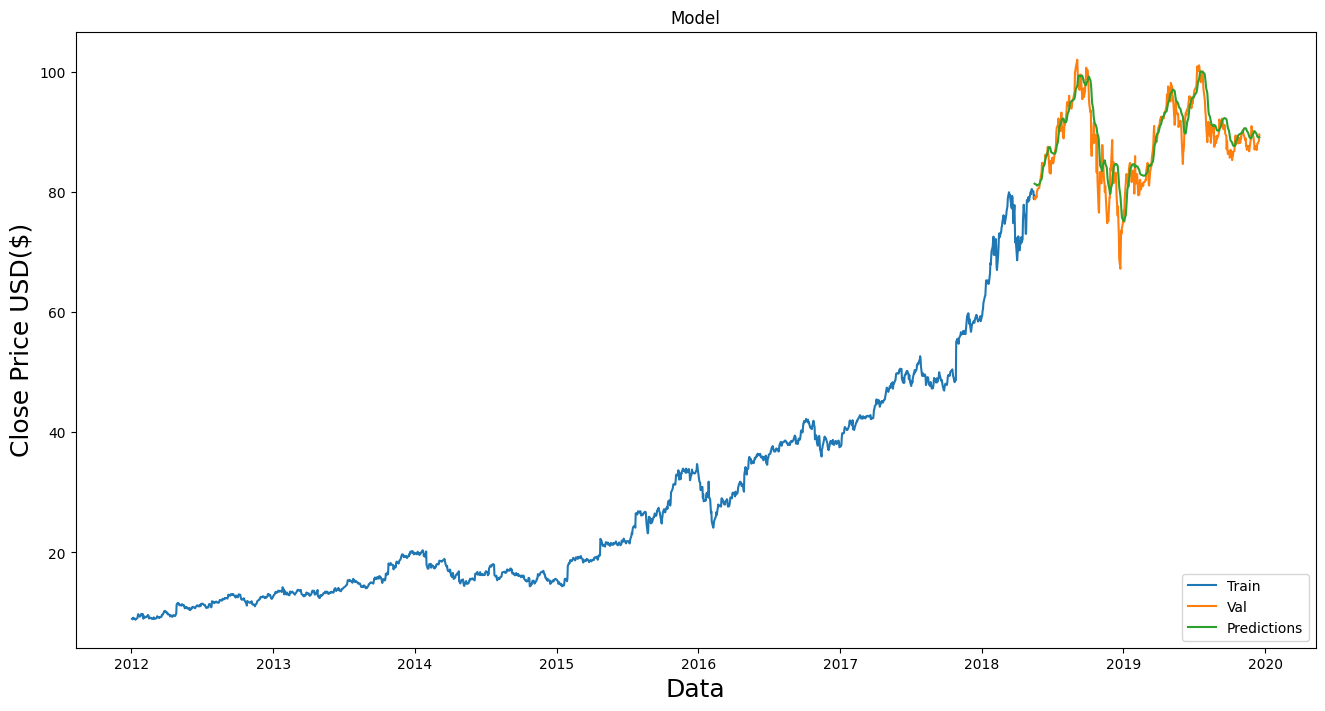

Processing MSFT.


<ipython-input-54-d8f9745a33f8>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


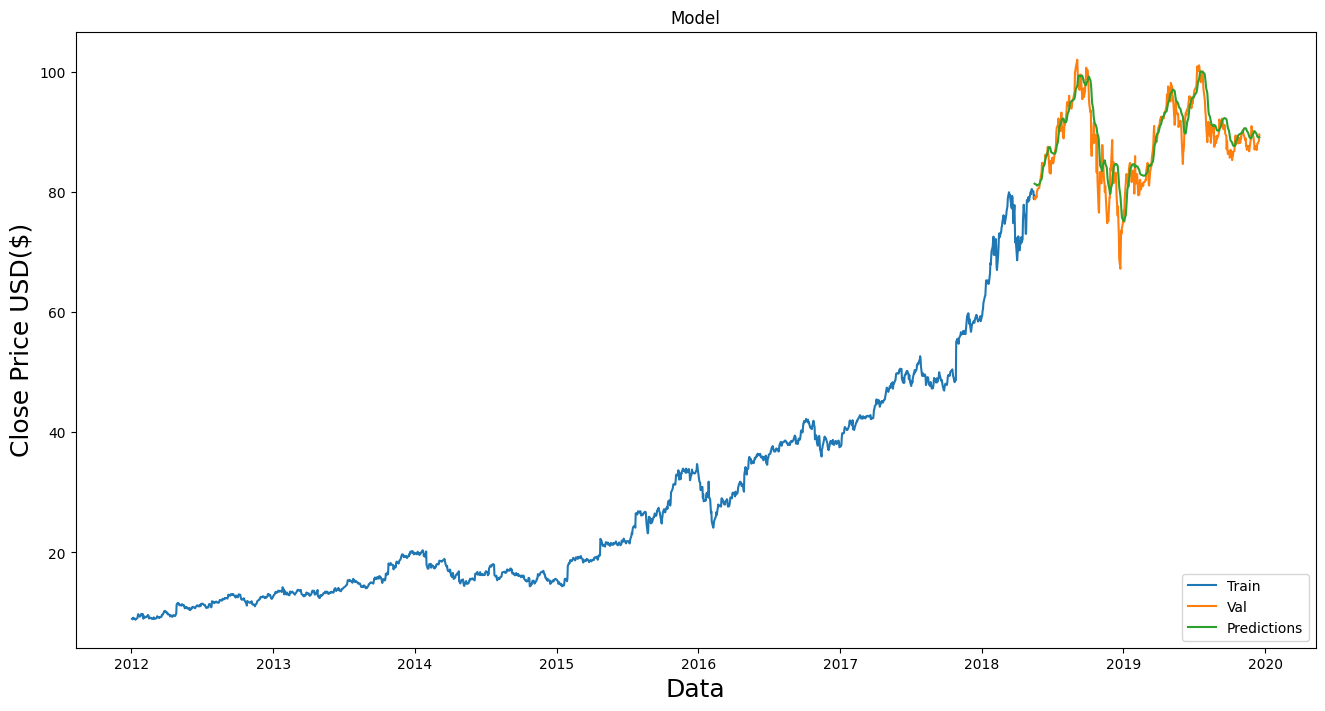

Processing GOOG.


<ipython-input-54-d8f9745a33f8>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


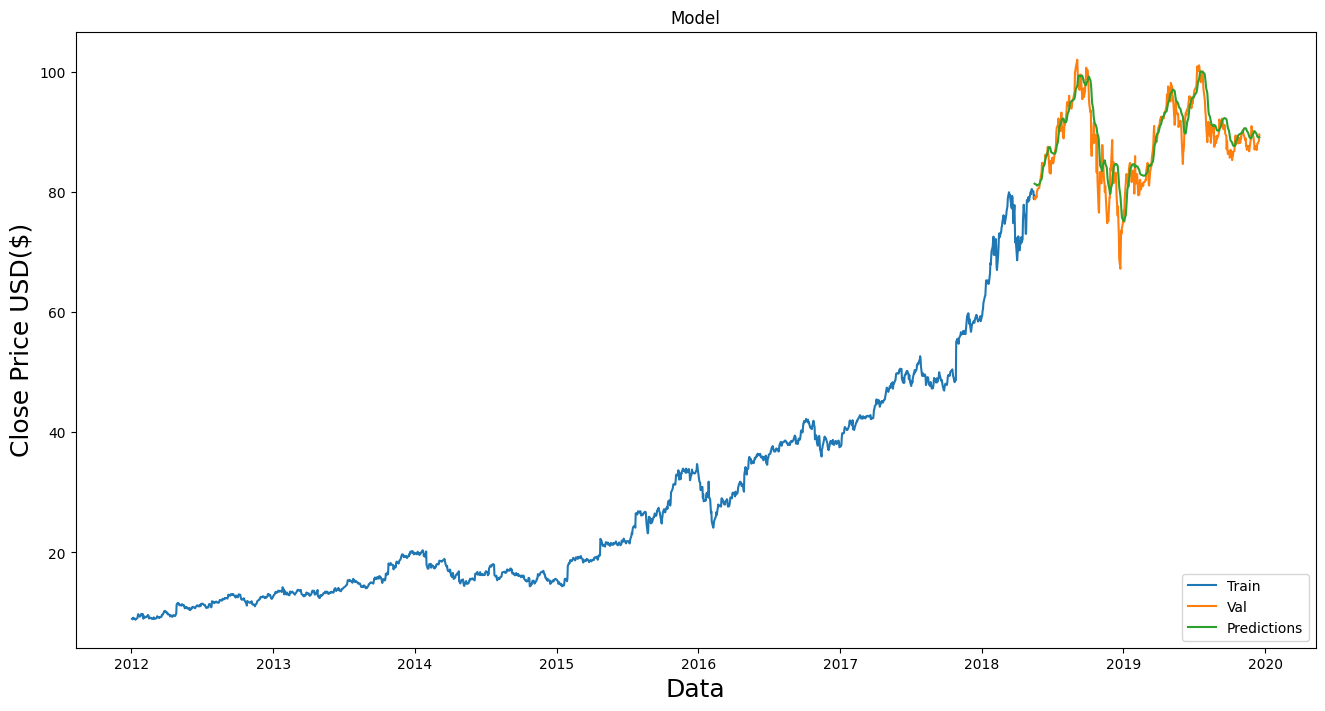

Processing NVDA.


<ipython-input-54-d8f9745a33f8>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


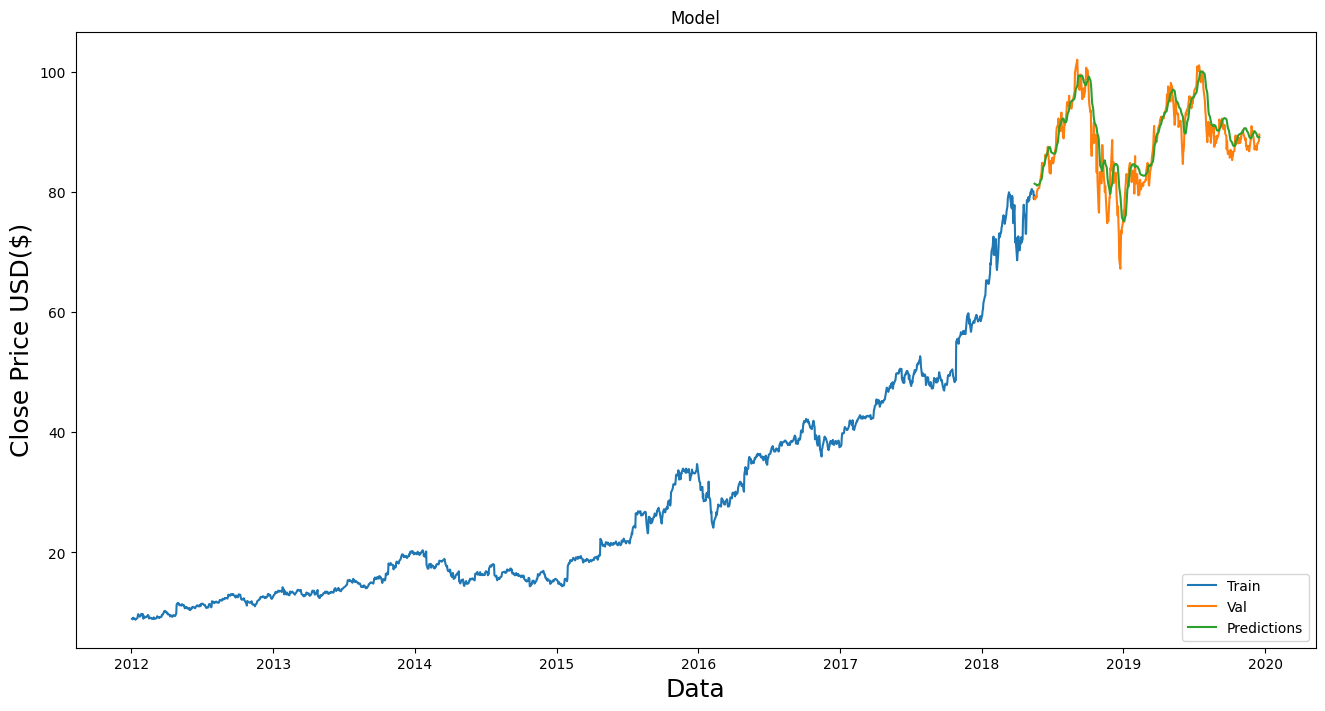

Processing META.


<ipython-input-54-d8f9745a33f8>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


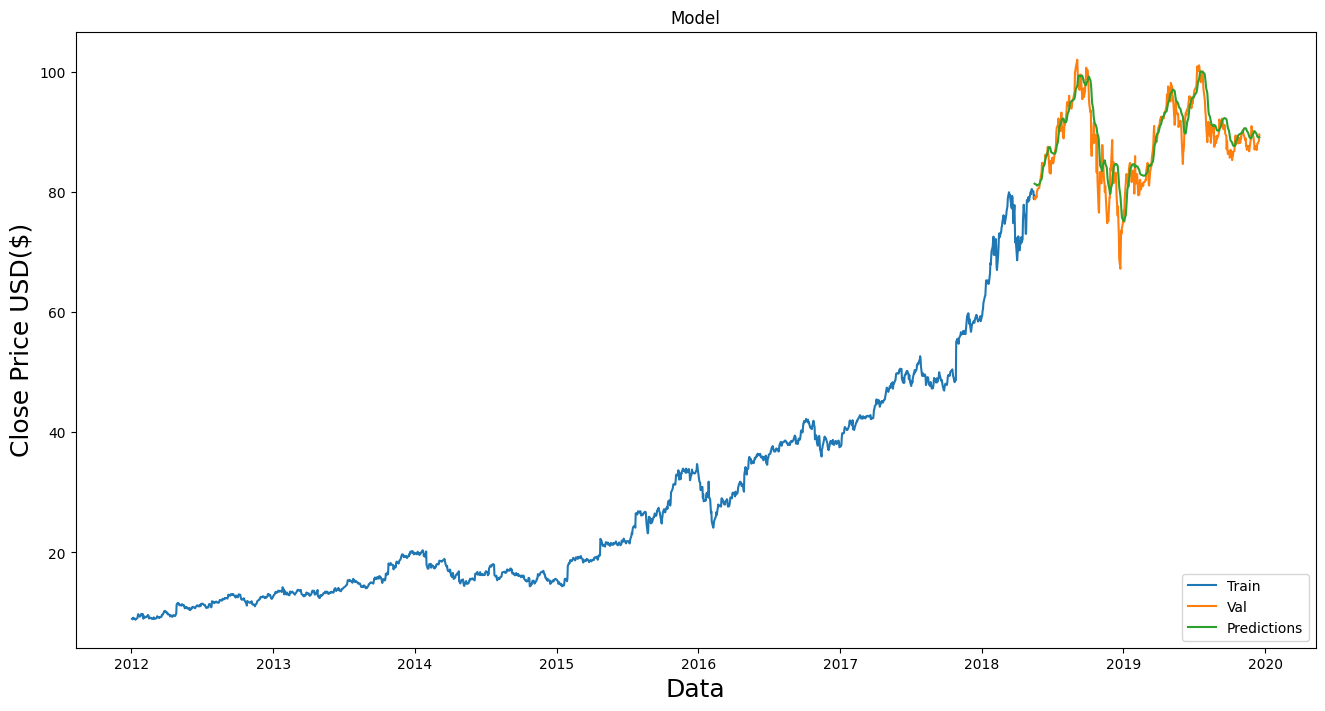

Processing AMZN.


<ipython-input-54-d8f9745a33f8>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


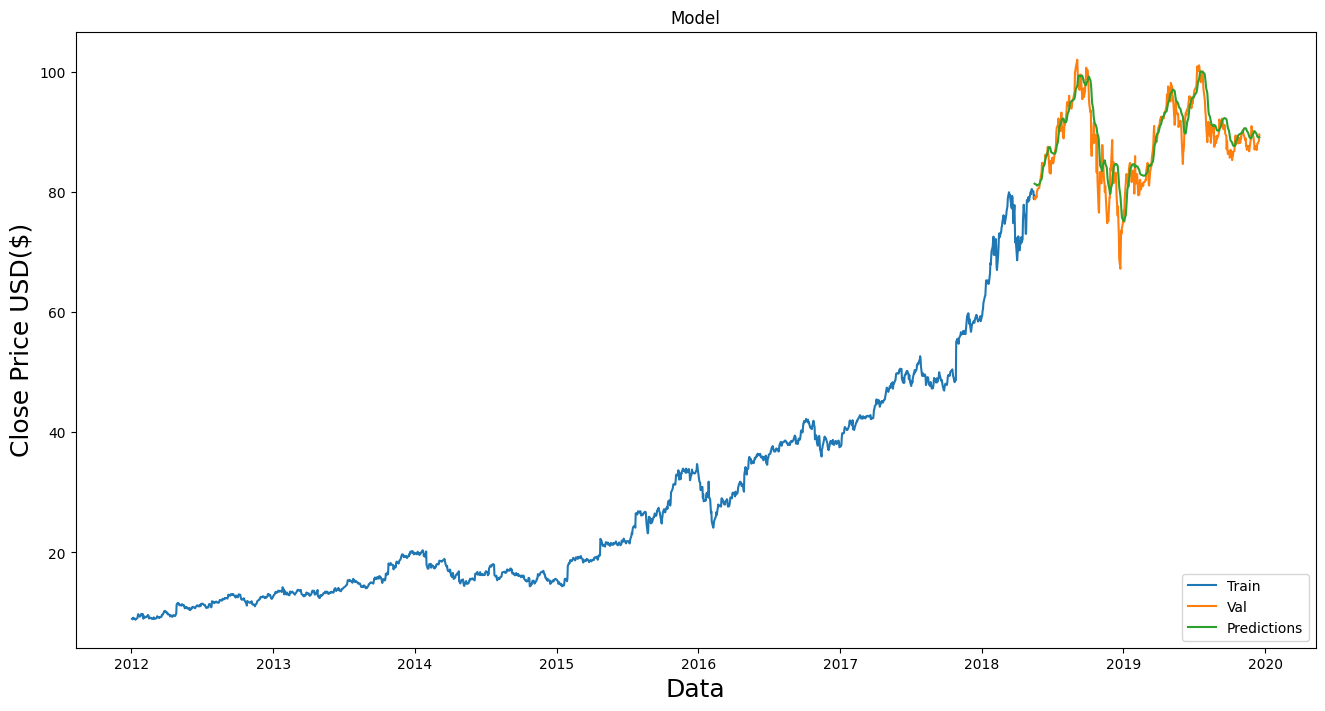

In [54]:
for stock in stocks:
  print(f"Processing {stock}.")
  #Plot the data
  train = data[:training_data_len]
  valid = data[training_data_len:]
  valid['Predictions'] = predictions
  #visualize the data
  plt.figure(figsize= (16,8))
  plt.title('Model')
  plt.xlabel('Data', fontsize = 18)
  plt.ylabel('Close Price USD($)', fontsize =18)
  plt.plot(train['Close'])
  plt.plot(valid[['Close', 'Predictions']])
  plt.legend(['Train', 'Val', 'Predictions'], loc = 'lower right')
  plt.show()

In [55]:
# Show the valid and predicted prices of stock price
for stock in stocks:
  print(f"Processing {stock}.")
  print(valid)

Processing AAPL.
              Close  Predictions
Date                            
2018-05-17  79.0880    81.348946
2018-05-18  78.7185    81.303482
2018-05-21  79.2730    81.202240
2018-05-22  79.0700    81.120468
2018-05-23  80.0930    81.040268
...             ...          ...
2019-12-11  87.4360    89.376343
2019-12-12  88.0165    89.196693
2019-12-13  88.0470    89.097610
2019-12-16  88.4605    89.055397
2019-12-17  89.5330    89.082420

[400 rows x 2 columns]
Processing MSFT.
              Close  Predictions
Date                            
2018-05-17  79.0880    81.348946
2018-05-18  78.7185    81.303482
2018-05-21  79.2730    81.202240
2018-05-22  79.0700    81.120468
2018-05-23  80.0930    81.040268
...             ...          ...
2019-12-11  87.4360    89.376343
2019-12-12  88.0165    89.196693
2019-12-13  88.0470    89.097610
2019-12-16  88.4605    89.055397
2019-12-17  89.5330    89.082420

[400 rows x 2 columns]
Processing GOOG.
              Close  Predictions
Date      

In [70]:
accuracyOfAllStocks =0;
for stock in stocks:
  print(f"Processing {stock}.")
  # Get the quote
  stock_quote = web.DataReader(stock, data_source ='stooq', start = '2012-01-01', end = '2019-12-17')
  # Create a new data frame
  new_df = stock_quote.filter(['Close'])
  new_df.sort_values(by = ['Date'], inplace = True)
  #Get the last 60 day closing prices values and convert dataframe into an array
  last_60_days = new_df[-60:].values
  #Scale the data to be values between 0 and 1
  last_60_days_scaled = scaler.transform(last_60_days)
  #Create an empty list
  X_test = []
  #Append the past 60 days
  X_test.append(last_60_days_scaled)
  #Convert x_test data set to a numpy array
  X_test = np.array(X_test)
  # Reshape the data
  X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
  # Get the predicted scaled price
  pred_price = model.predict(X_test)
  #undo the scaling
  pred_price = scaler.inverse_transform(pred_price)
  print(f"Predicting Closing price: {pred_price}")
  # Get the actual price
  accuracyOfAllStocks =0;
  stock_quote2 = web.DataReader(stock, data_source ='stooq', start = '2019-12-18', end = '2019-12-18')
  actual_price = stock_quote2['Close'].values[0] # Extracting the single closing price value
  print(f"Actual Closing Price: {actual_price}")
  accuracy = 100 - ((pred_price[0][0]-stock_quote)/ stock_quote) *100
  accuracyOfAllStocks += accuracy




Processing AAPL.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicting Closing price: [[68.40625]]
Actual Closing Price: 68.516
Processing MSFT.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicting Closing price: [[139.963]]
Actual Closing Price: 150.077
Processing GOOG.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicting Closing price: [[69.05383]]
Actual Closing Price: 67.631
Processing NVDA.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicting Closing price: [[5.834117]]
Actual Closing Price: 5.71503
Processing META.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicting Closing price: [[172.81483]]
Actual Closing Price: 202.5
Processing AMZN.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicting Closing price: [[89.230125]]
Actual Closing Price: 89.2015
Accuracry of LSTM model :                   Open        High         Low       Close     Volume
Date                                                                 
2019-12-17   16.604870   16.735468   16.599035   16.723047  33.333313
2019-12-16   16.500637 